2. ii) Clustering of RNA-Seq based on expression profile

In this Notebook we used different Clustering techniques to analyze differentially expressed genes between ILC subypes to determine if clustering based on the expression profile was possible. 

In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import umap
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


/Users/paulagutierrezposse/miniconda3/envs/data_analysis/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
expression_df = pd.read_csv("./data/mmc2.csv", usecols = ["NK.27+11b-.BM","NK.27+11b+.BM","NK.27-11b+.BM","NK.27+11b-.Sp","NK.27+11b+.Sp","NK.27-11b+.Sp","ILC2.SI", "ILC3.NKp46-CCR6-.SI", "ILC3.NKp46+.SI", "ILC3.CCR6+.SI"])

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(expression_df)

In [8]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

/Users/paulagutierrezposse/miniconda3/envs/data_analysis/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/paulagutierrezposse/miniconda3/envs/data_analysis/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


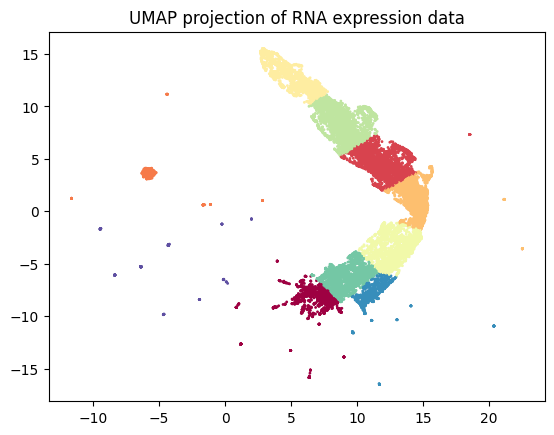

In [9]:
from sklearn.cluster import KMeans
clusters = KMeans(n_clusters=10).fit_predict(X_umap)
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap='Spectral', s=1)
plt.title('UMAP projection of RNA expression data')
plt.savefig('umap_clusters.png', dpi=300)

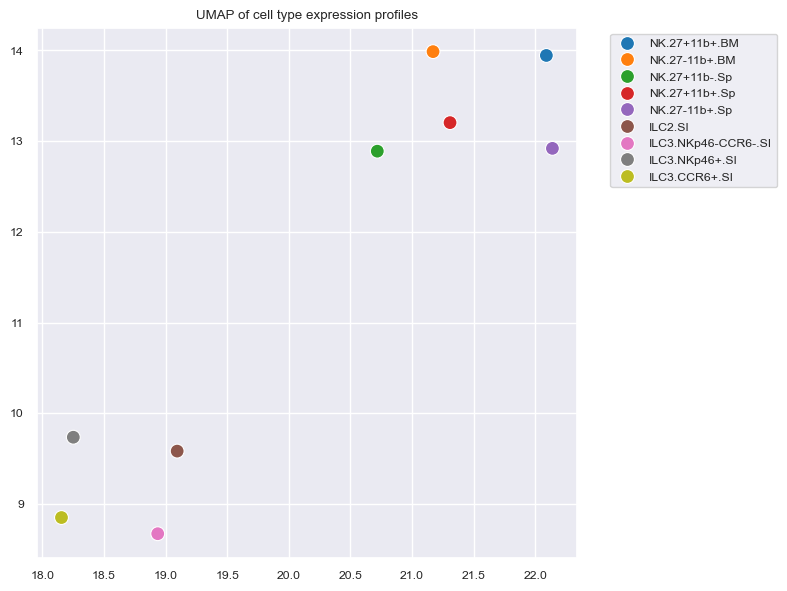

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans

expression_df = pd.read_csv("./data/mmc2.csv", usecols=[
    "NK.27+11b-.BM", "NK.27+11b+.BM", "NK.27-11b+.BM",
    "NK.27+11b-.Sp", "NK.27+11b+.Sp", "NK.27-11b+.Sp",
    "ILC2.SI", "ILC3.NKp46-CCR6-.SI", "ILC3.NKp46+.SI", "ILC3.CCR6+.SI"
], index_col=0)  

expression_t = expression_df.T

scaler = StandardScaler()
X_scaled = scaler.fit_transform(expression_t)

reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

clusters = KMeans(n_clusters=4, random_state=42).fit_predict(X_umap)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=expression_t.index, palette='tab10', s=100)
plt.title("UMAP of cell type expression profiles")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("umap_celltypes.png", dpi=300)
plt.show()

According to the UMAP Projection we can visualize that ILC have a differentiation pathway. Also when we perform UMAP clustering per subtype it can be concluded that in our cells we have to different subgroups, ILC and NK, with sloghtly different expression profiles. To further confirm this theory, we calculated log2-fold to find upregulated genes in every subtype and then visualized them in a heatmap. 

a) Can you determine a specific set of genes for your cell lineage?


Finding top 50 more variable Genes across ILC subtypes by calculating log2-Fold and z-score.

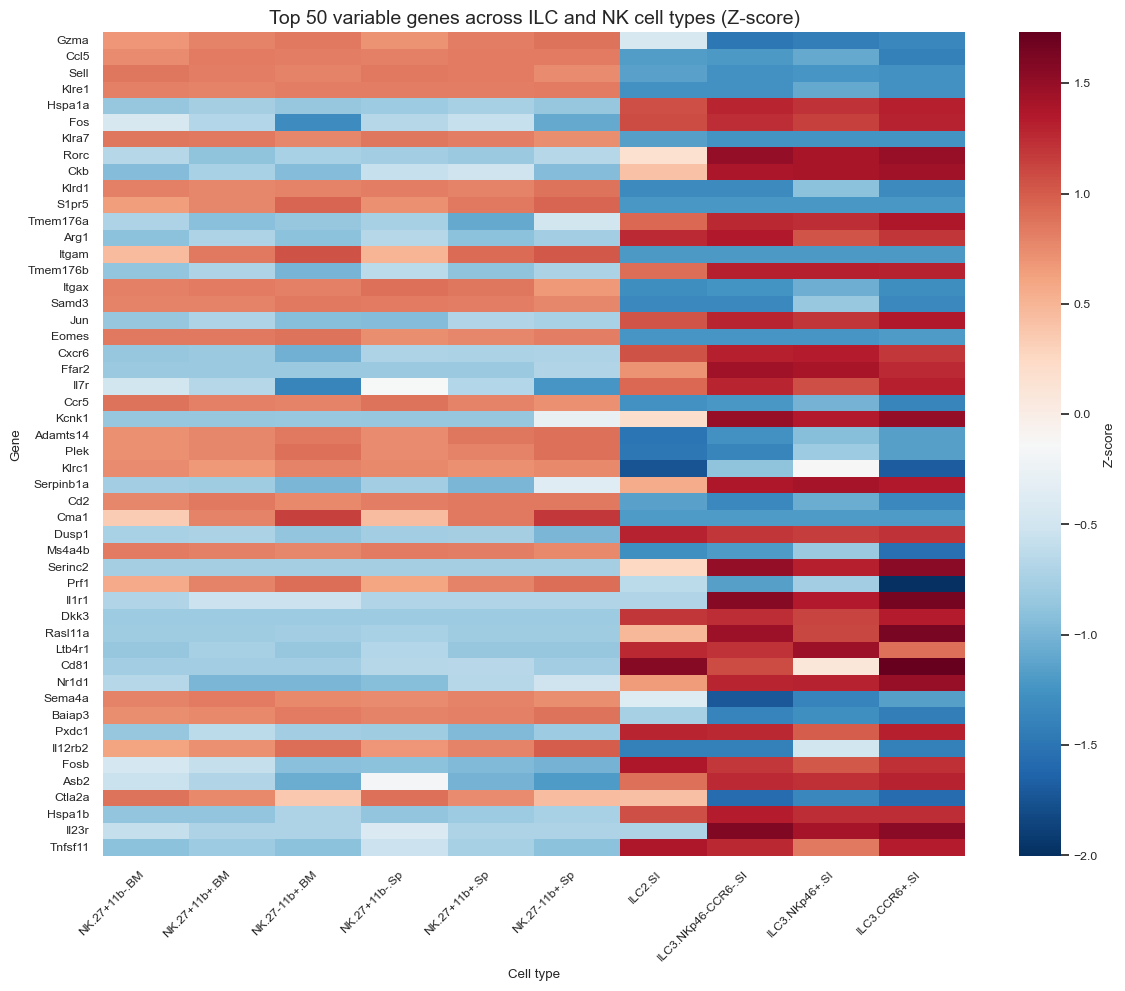

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

expression_df = pd.read_csv("data/mmc2.csv", index_col=0)

cell_types = [
    "NK.27+11b-.BM", "NK.27+11b+.BM", "NK.27-11b+.BM",
    "NK.27+11b-.Sp", "NK.27+11b+.Sp", "NK.27-11b+.Sp",
    "ILC2.SI", "ILC3.NKp46-CCR6-.SI", "ILC3.NKp46+.SI", "ILC3.CCR6+.SI"
]

sub_df = expression_df[cell_types]

sub_df_log = np.log2(sub_df + 1)

gene_variances = sub_df_log.var(axis=1)
top_variable_genes = gene_variances.sort_values(ascending=False).head(50).index
top_df = sub_df_log.loc[top_variable_genes]

scaler = StandardScaler()
top_df_scaled = pd.DataFrame(
    scaler.fit_transform(top_df.T).T,  
    index=top_df.index,
    columns=top_df.columns
)

plt.figure(figsize=(12, 10))
sns.heatmap(top_df_scaled, cmap="RdBu_r", xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Z-score'})
plt.title("Top 50 variable genes across ILC and NK cell types (Z-score)", fontsize=14)
plt.xlabel("Cell type")
plt.ylabel("Gene")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("heatmap_ILC_NK_top50_genes.png", dpi=300)
plt.show()

Using this heatmap we can see that every cell subtype has their own expression profile and upregulated genes comparing the expression in all other subtypes. 

b) Are there subclusters of special interest?

Hierarchical Clustering for RNA-seq

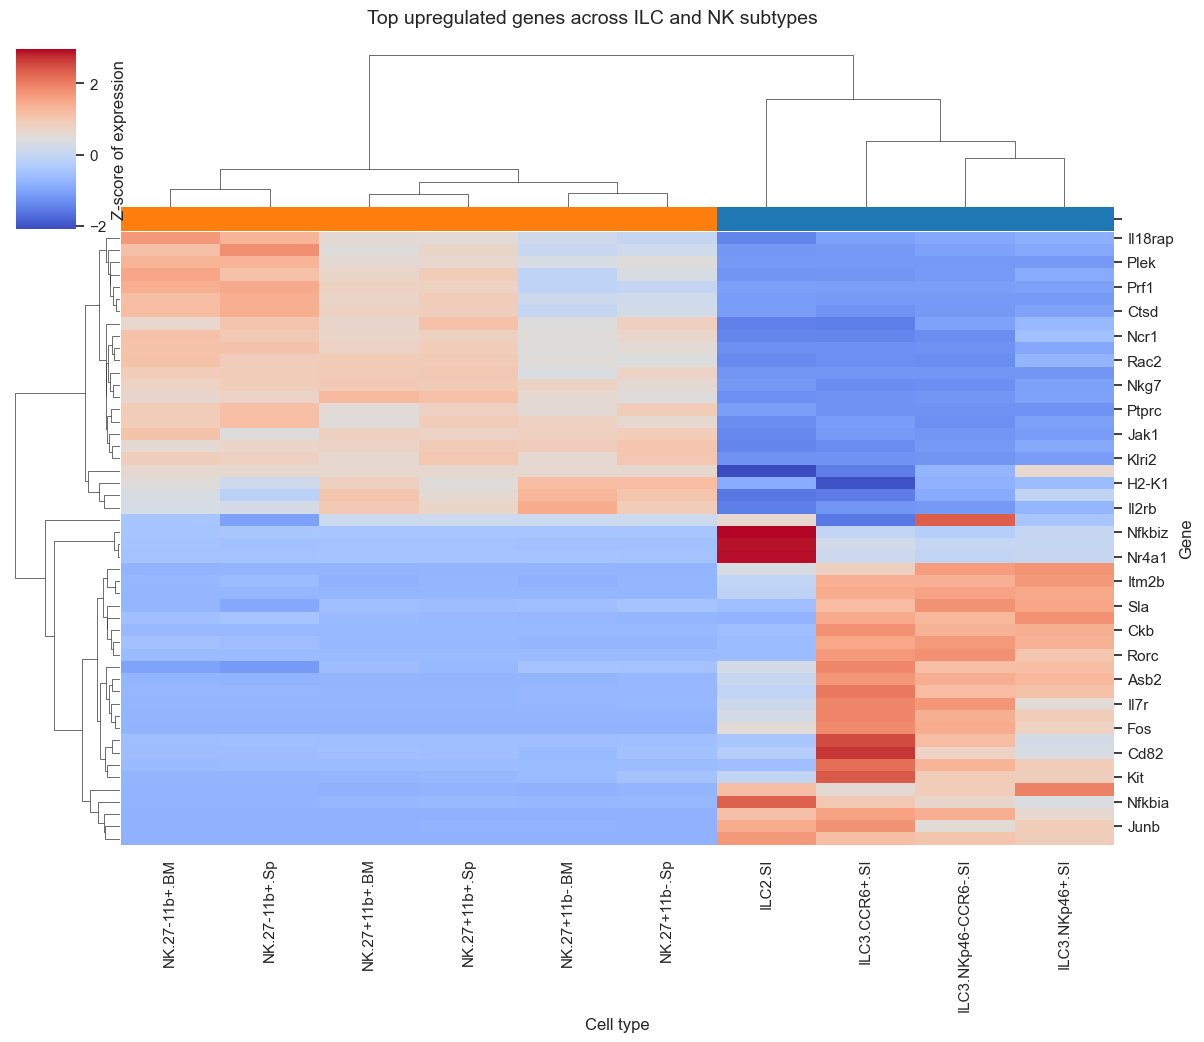

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

expression_df = pd.read_csv("data/mmc2.csv", index_col=0)

cell_types = [
    "ILC2.SI", "ILC3.NKp46-CCR6-.SI", "ILC3.NKp46+.SI", "ILC3.CCR6+.SI",
    "NK.27+11b-.BM", "NK.27+11b+.BM", "NK.27-11b+.BM",
    "NK.27+11b-.Sp", "NK.27+11b+.Sp", "NK.27-11b+.Sp"
]

subset_df = expression_df[cell_types]

top_var_genes = subset_df.var(axis=1).sort_values(ascending=False).head(50).index
subset_df = subset_df.loc[top_var_genes]

scaler = StandardScaler()
zscored_data = pd.DataFrame(
    scaler.fit_transform(subset_df.T).T,
    index=subset_df.index,
    columns=subset_df.columns
)

group_labels = ["ILC"] * 4 + ["NK"] * 6
palette = {"ILC": "#1f77b4", "NK": "#ff7f0e"}
col_colors = pd.Series(group_labels, index=cell_types).map(palette)

sns.set(context="notebook", style="white")
g = sns.clustermap(
    zscored_data,
    cmap="coolwarm",  
    col_cluster=True,
    row_cluster=True,
    col_colors=col_colors,
    figsize=(12, 10),
    dendrogram_ratio=(0.1, 0.2),
    cbar_kws={'label': 'Z-score of expression'}
)

plt.suptitle("Top upregulated genes across ILC and NK subtypes", y=1.02, fontsize=14)
g.ax_heatmap.set_xlabel("Cell type", fontsize=12)
g.ax_heatmap.set_ylabel("Gene", fontsize=12)

plt.savefig("heatmap_ILC_NK_genes.png", dpi=300, bbox_inches="tight")
plt.show()

We then also performed a hierarchical cluster with the most variable genes that were analyzed before to determine subclusters between ILC that can be compared with the results from before when comparing only the top upregulated genes. Seeing the clusters and names of each subtype we can see that it makes sense, in general NK cells cluster together and ILC too. In NK cells NK.27- cluster together and NK.27+ too, then NK.27+ cells cluster based on 11b. We can see that the organ from which the cells were extracted also influences the expression profile. 

In [113]:
cluster_data_z

,ILC2.SI,ILC3.NKp46-CCR6-.SI,ILC3.NKp46+.SI,ILC3.CCR6+.SI,NK.27+11b-.BM,NK.27+11b+.BM,NK.27-11b+.BM,NK.27+11b-.Sp,NK.27+11b+.Sp,NK.27-11b+.Sp
Gene,,,,,,,,,,
Junb,1.365280,0.513523,0.850120,1.697935,-0.728758,-0.738090,-0.738989,-0.752255,-0.726528,-0.742239
Gzma,-1.069251,-1.083666,-1.083598,-1.083505,0.123627,0.686400,1.110851,0.177440,0.871770,1.349932
Jun,0.249786,1.332330,0.864755,1.833378,-0.713920,-0.712320,-0.714538,-0.714732,-0.711997,-0.712742
Tnfaip3,2.742916,-0.002436,0.003806,0.193590,-0.497209,-0.492653,-0.474530,-0.495196,-0.483373,-0.494914
Ptprc,-1.021549,-1.196700,-1.172765,-1.185493,0.544639,0.489163,0.857453,0.857453,0.731158,1.096640
...,...,...,...,...,...,...,...,...,...,...
Gzmb,-0.918366,-0.914214,-0.902172,-0.904680,-0.277396,0.603084,1.481247,-0.384077,0.634164,1.582411
Vim,-1.253520,-1.431440,-0.637027,-1.058057,0.966904,1.020564,0.949095,0.072844,0.557809,0.812827
Laptm5,-1.145461,-0.691075,0.265626,-1.127665,-0.857008,0.469201,1.527306,-0.429290,0.536045,1.452322


Now we wanted to compare the expression profile from ILC with all other cell types from the dataset to wee if they cluster together and teremine gene clusters that differentiate our cell types from the others.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

expr = pd.read_csv('./data/mmc2.csv', index_col=0)

def assign_group(col_name):
    if 'NK.27' in col_name:
        return 'NK.27'
    elif 'ILC' in col_name:
        return 'ILC'
    else:
        return 'Other'

groups = expr.columns.to_series().apply(assign_group)

nk_samples = groups[groups == 'NK.27'].index
ilc_samples = groups[groups == 'ILC'].index
other_samples = groups[groups == 'Other'].index

selected_samples = nk_samples.tolist() + ilc_samples.tolist()

results = []
for gene in expr.index:
    group1 = expr.loc[gene, selected_samples]
    group2 = expr.loc[gene, other_samples]
    stat, pval = ttest_ind(group1, group2, equal_var=False)
    mean_diff = group1.mean() - group2.mean()
    results.append({'gene': gene, 'pval': pval, 'mean_diff': mean_diff})

de_df = pd.DataFrame(results)
de_df = de_df.sort_values(by='mean_diff', ascending=False)

top_genes = de_df.head(30)['gene'].tolist()

In [139]:
top_genes

['Gzma',
 'Junb',
 'Klrk1',
 'Jun',
 'H2-K1',
 'Nkg7',
 'Ccl5',
 'AW112010',
 'Ptprc',
 'Il2rb',
 'Ncr1',
 'Klrb1c',
 'Jak1',
 'Id2',
 'Prf1',
 'Fos',
 'Itm2b',
 'Il18rap',
 'Klri2',
 'Dusp1',
 'Actb',
 'Selplg',
 'Sepp1',
 'Tnfaip3',
 'Ctsd',
 'Gimap4',
 'Ahnak',
 'Itgb2',
 'Anxa2',
 'Gimap3']

We are going to identify the more variable genes across all cell types and do a hierarchical clustering to see if cell types cluster together. Then we are going to find lineage specific genes by filtering for high expression and variability of genes on ILC. Lastly we are going to uncover subclusters by doing a PCA of the ILC subtypes based on gene expression profiles. 

Lineage specific genes (high expression and variability):
               NK.27+11b-.BM  NK.27+11b+.BM  NK.27-11b+.BM  NK.27+11b-.Sp  \
Unnamed: 0                                                                  
1600012H06Rik     236.881137     209.593331     275.047443     243.691493   
1700017B05Rik      66.903976      41.121193      18.042403      38.267080   
1700025G04Rik     253.954200     223.544930     265.315442     236.505089   
1700066M21Rik      55.245910      80.314247      59.541966      69.810335   
1810011H11Rik       1.025543       1.594514       1.035532       1.024781   

               NK.27+11b+.Sp  NK.27-11b+.Sp      ILC2.SI  ILC3.NKp46-CCR6-.SI  \
Unnamed: 0                                                                      
1600012H06Rik     283.154324     353.180315    64.332881            91.520026   
1700017B05Rik      43.103969      40.368802   113.357721           228.505706   
1700025G04Rik     232.556429     254.026331    10.745456             1.271327 

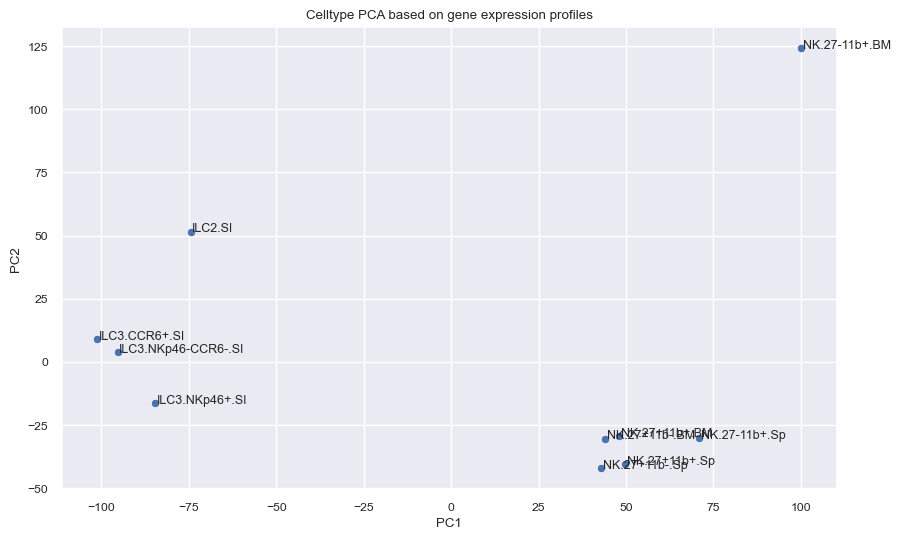

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

file_path = "./data/mmc2.csv"  
df = pd.read_csv(file_path)
genes = df["Unnamed: 0"]
expression_data = df.drop(columns=["Unnamed: 0"])

gene_variances = expression_data.var(axis=1)
top_genes_idx = gene_variances.sort_values(ascending=False).head(500).index
top_genes = expression_data.iloc[top_genes_idx]

scaler = StandardScaler()
scaled_top_genes = scaler.fit_transform(top_genes)

linkage_matrix_top = linkage(scaled_top_genes, method="ward")

cell_types_of_interest = [
    "NK.27+11b-.BM", "NK.27+11b+.BM", "NK.27-11b+.BM",
    "NK.27+11b-.Sp", "NK.27+11b+.Sp", "NK.27-11b+.Sp",
    "ILC2.SI", "ILC3.NKp46-CCR6-.SI", "ILC3.NKp46+.SI", "ILC3.CCR6+.SI"
]

subset_expr = df[cell_types_of_interest]
subset_expr.index = genes

mean_expression = subset_expr.mean(axis=1)
std_expression = subset_expr.std(axis=1)
cv_relative = std_expression / (mean_expression + 1e-6)

specific_genes_mask = (mean_expression > 50) & (cv_relative > 0.5)
specific_genes = subset_expr[specific_genes_mask]

print("Lineage specific genes (high expression and variability):")
print(specific_genes.head())

transposed = subset_expr.T
scaled_cells = scaler.fit_transform(transposed)

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_cells)

pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"], index=transposed.index)

plt.figure(figsize=(10, 6))
sns.scatterplot(x="PC1", y="PC2", data=pca_df)
for i in pca_df.index:
    plt.text(pca_df.loc[i, "PC1"]+0.5, pca_df.loc[i, "PC2"], i, fontsize=9)
plt.title("Celltype PCA based on gene expression profiles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

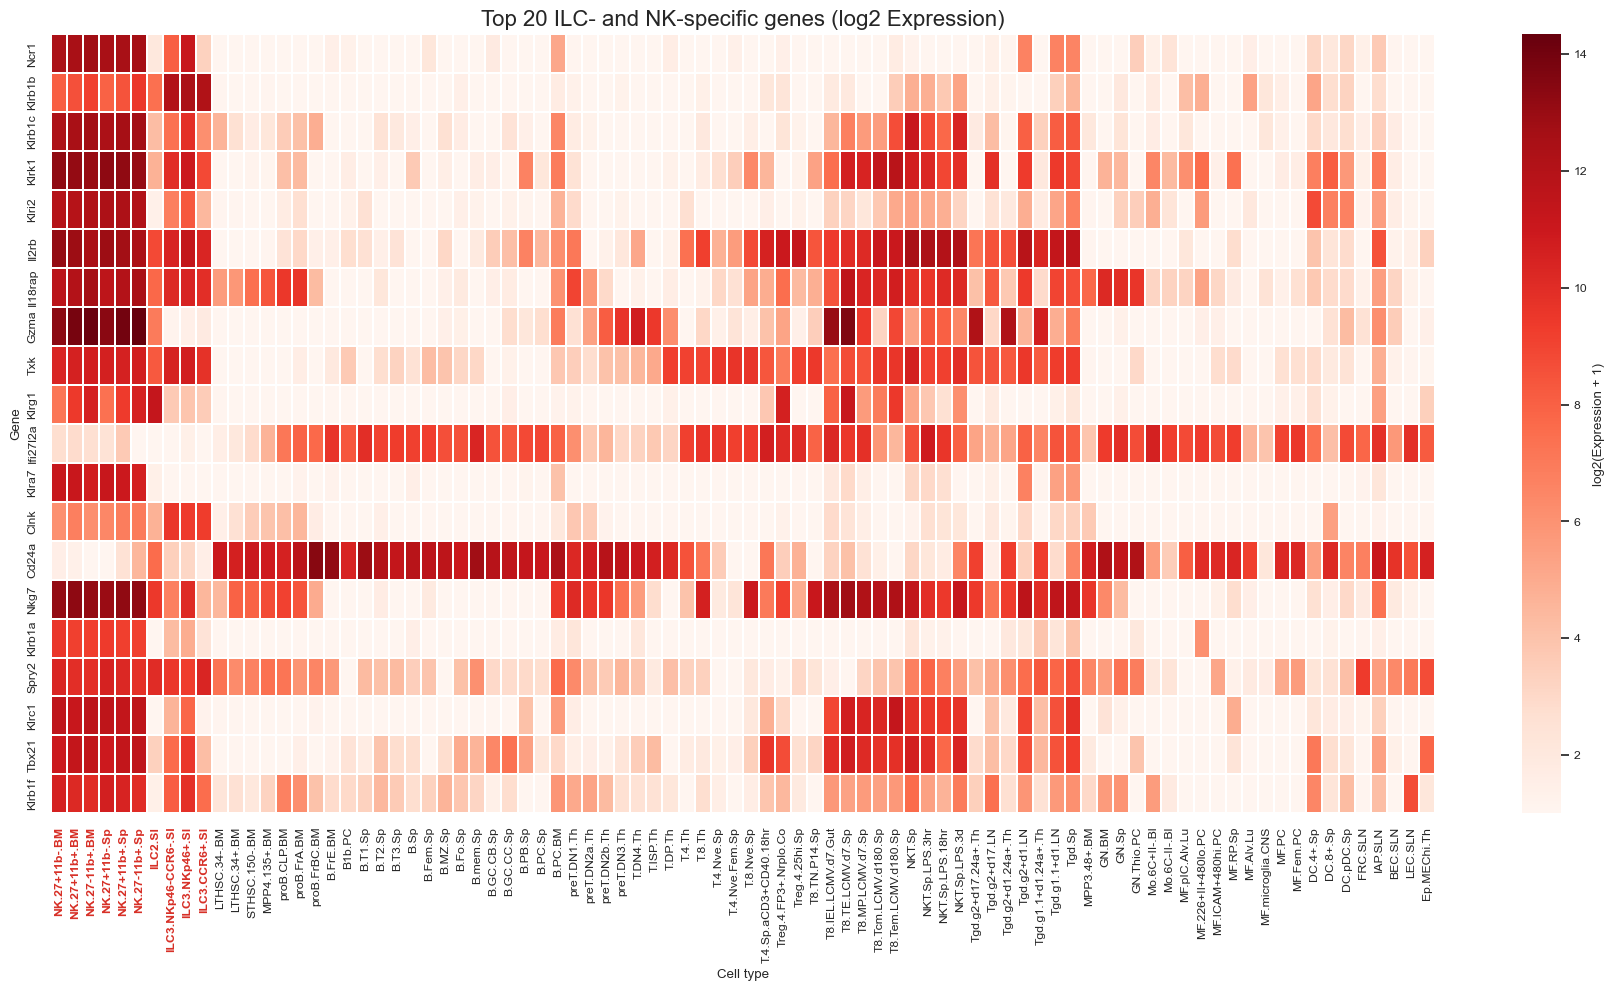

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/mmc2.csv", index_col=0)

my_celltypes = [
    "NK.27+11b-.BM", "NK.27+11b+.BM", "NK.27-11b+.BM",
    "NK.27+11b-.Sp", "NK.27+11b+.Sp", "NK.27-11b+.Sp",
    "ILC2.SI", "ILC3.NKp46-CCR6-.SI", "ILC3.NKp46+.SI", "ILC3.CCR6+.SI"
]

df_log2 = df.apply(lambda x: np.log2(x + 1))

mean_in = df_log2[my_celltypes].mean(axis=1)
mean_out = df_log2.drop(columns=my_celltypes).mean(axis=1)
log2fc = mean_in - mean_out

top_genes = log2fc.abs().sort_values(ascending=False).head(20).index
top_expr = df_log2.loc[top_genes]

ordered_cols = my_celltypes + [c for c in df_log2.columns if c not in my_celltypes]
top_expr = top_expr[ordered_cols]

col_colors = ['#d73027' if c in my_celltypes else '#f0f0f0' for c in ordered_cols]

plt.figure(figsize=(18, 10))
sns.heatmap(
    top_expr,
    cmap="Reds",
    cbar_kws={"label": "log2(Expression + 1)"},
    linewidths=0.05,
    xticklabels=True,
    yticklabels=True
)

ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
for label in ax.get_xticklabels():
    if label.get_text() in my_celltypes:
        label.set_color('#d73027')
        label.set_fontweight('bold')

plt.title("Top 20 ILC- and NK-specific genes (log2 Expression)", fontsize=16)
plt.xlabel("Cell type")
plt.ylabel("Gene")

plt.tight_layout()
plt.savefig("Specific_Genes.png", dpi=300)
plt.show()

In conslusion from this other approach, re specific genes that express higher on ILC. Also subclusters can be identified when using PCA. The theory that ILC cluster together and NK cells too is also confirmed by this approach. ILC belong to PC2 and NK cells to PC1 in exception of NK.27-11b+.BM that belongs to both PCA clusters. 

ILC can be clustered based on gene expression.